# Building Distributions

The purpose of this notebook is to build some canonical distributions used for convergence testing. 
These include
- normal distribution
- geometric distribution
- binomial distribution


In [101]:
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tabulate import tabulate



We begin by building a normal distribution 
$$
 X \sim N(0, 2)
$$

Where we want to estimate this quantity 
$$
E(X^2)
$$

using $N$ samples $X_1, \ldots, X_N$ and estimator:

$$
\mu_N  = \frac{1}{N} \sum_{i=1}^N X_i^2
$$

(array([1., 0., 1., 0., 3., 0., 2., 1., 1., 1.]),
 array([-5.92905768, -4.85206891, -3.77508014, -2.69809137, -1.6211026 ,
        -0.54411383,  0.53287494,  1.60986371,  2.68685248,  3.76384125,
         4.84083002]),
 <BarContainer object of 10 artists>)

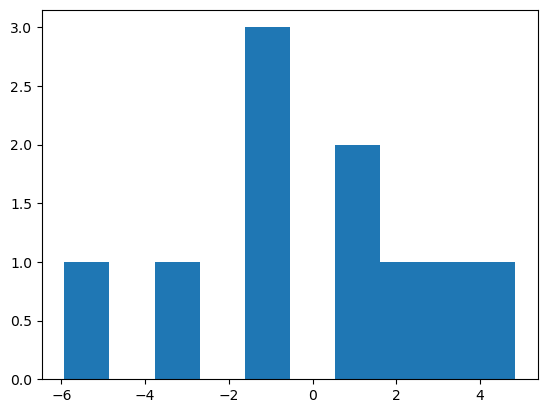

In [ ]:
# building a distribution:

# seeding
rng = np.random.default_rng(seed=42)

# get an array of norm rnds
# generate N samples:
N = 10
sigma = 2.0
true_mean = 0.0
X = rng.normal(loc=true_mean, scale=sigma, size=N)

# make normal distro. check with plot
plt.hist(rnd_array)




# Build an Estimator


In [ ]:
# lets build estimator for quantity E(X^2).

# for a X~N(0, 2), we get 4? Var(X) = E(X^2) - E(X)^2 = E(X^2) = 4. 


# to build the estimator design it:
# seeding
# rng = np.random.default_rng(seed=42)

# Distribution Params.
sigma = 2.0
true_mean = 0.0

# Get N numbers. This will loop later. 

# Storing data.
estimator_mean = []
estimator_sdev = []
estimator_rmse = []
# error_abs_mean = []
runtime_mean = []

# Executing Loop. 
log_sample_size = [10 ** i for i in range(1, 7)]
repeat_draw_size = 100
repeat_draws = range(1, repeat_draw_size + 1) # Doing 1 draw per sample size is noisy. Make several draws.
for N in log_sample_size:
    # Storing data.
    estimator = []
    error_abs = []
    runtime = []
    for draw in repeat_draws:
        time_start = time.perf_counter()

        # Draw the random numbers.
        X = rng.normal(loc=true_mean, scale=sigma, size=N)

        # Calculate QOIs.
        mu_n = sum([x ** 2 / N for x in X])
        estimator.append(mu_n)
        # error_abs.append(abs(mu_n - sigma ** 2))

        time_end = time.perf_counter()
        runtime.append(time_end - time_start)
    
    # Compute mean of estimates.
    estimator_mean.append(sum(estimator) / repeat_draw_size)
    # error_abs_mean.append(sum(error_abs) / repeat_draw_size)
    runtime_mean.append(sum(runtime) / repeat_draw_size)

    # Compute stan dev of estimates.
    # This is a biased estimator of stan dev but for large sample size (repeat_draw_size), the difference is negligible.
    estimator_sdev.append(sum([(x - estimator_mean[-1]) ** 2 for x in estimator]) / (repeat_draw_size - 1))
    estimator_rmse.append(sum([(sigma ** 2 - y_hat) ** 2 for y_hat in estimator]) / repeat_draw_size)



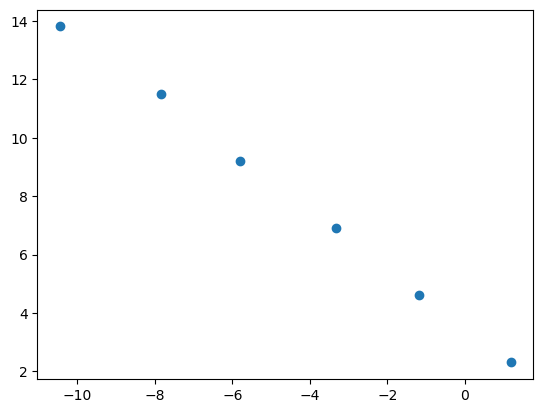

In [ ]:
# compare against theory

# MC theory says:
# Error proportional to 1/sqrt(N)


plt.scatter(np.log(estimator_rmse), np.log(log_sample_size))


(3.95, 4.05)

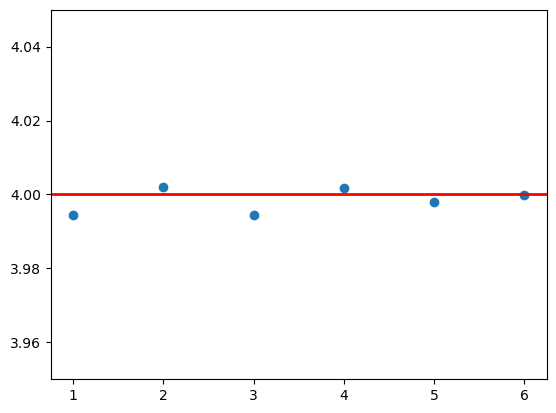

In [95]:

# Plot to verify 
x_space = [np.log10(x) for x in log_sample_size]
plt.scatter(x_space, estimator_mean)
plt.axhline(y=sigma ** 2, color="red", linestyle="-", linewidth=2)
# plt.xlim(0, 5)
plt.ylim(3.95, 4.05)